# BioJEPA v0.6 Training Pipeline

In [1]:
import torch
import random
import gc
import matplotlib.pyplot as plt
from pathlib import Path

from biojepa_v0_6 import BioJepa, BioJepaConfig
from dataloader_v0_6 import PretrainLoader, AlignmentLoader, TrainingLoader
from training_v0_6 import create_model, load_feature_banks, run_pretraining, run_alignment, run_full_training, train_linear_decoder
from config_v0_6 import PretrainConfig, AlignmentConfig, FullTrainingConfig, DecoderConfig, DataConfig
from evals.evals import EvalContext, run_pretraining_evals, run_alignment_evals, run_full_model_evals, save_report

## Device & Paths

In [ ]:
def get_device():
    device = 'cpu'
    if torch.cuda.is_available():
        torch.cuda.manual_seed(1337)
        device = 'cuda'
    print(f'using {device}')
    return device

torch.manual_seed(1337)
random.seed(1337)
torch.set_float32_matmul_precision('high')

device = get_device()

data_root = Path('/Users/djemec/data/jepa/v0_6')

data_cfg = DataConfig(
    data_root=data_root,
    checkpoint_dir=data_root / 'checkpoints',
    eval_results_dir=data_root / 'eval_results'
)

## Hyperparameters

In [3]:
# Model architecture
model_cfg = BioJepaConfig(
    num_genes=5000,
    n_layer=2,
    heads=2,
    embed_dim=8,
    mlp_ratio=4.0,
    n_pre_layer=2,
    mask_ratio=0.6,
    gaussian_scale=2.0,
    film_linear_multiple=1.0,
    sim_coeff=25.0,
    std_coeff=25.0,
    cov_coeff=1.0,
    pert_latent_dim=320,
    pert_mode_dim=64
)

# Training configs
pt_cfg = PretrainConfig(epochs=1, lr=1e-3, batch_size=32)
align_cfg = AlignmentConfig(epochs=100, lr=4e-3, batch_size=32)
full_cfg = FullTrainingConfig(epochs=1, predictor_lr=1e-3, batch_size=32)
decoder_cfg = DecoderConfig(epochs=1, lr=1e-3)

## Initialize Model & Data

In [ ]:
model = create_model(model_cfg, device)
seq_banks, target_bank = load_feature_banks(data_cfg, device)

print(f'Student/Teacher: {sum(p.numel() for p in model.student.parameters() if p.requires_grad):,}')
print(f'ACpredictor: {sum(p.numel() for p in model.predictor.parameters() if p.requires_grad):,}')
print(f'PerturbationComposer: {sum(p.numel() for p in model.composer.parameters() if p.requires_grad):,}')

### Load pretraining model from checkpoint (for resuming)

In [5]:
# checkpoint_path = data_cfg.checkpoint_dir / 'biojepa_v0_6_pt_final.pt'
# with torch.serialization.safe_globals([BioJepaConfig]):
#     checkpoint = torch.load(checkpoint_path)

# keys = model.load_state_dict(checkpoint['model'])
# keys

## Pretraining

In [6]:
pt_train_loader = PretrainLoader(
    batch_size=pt_cfg.batch_size, 
    split='train', data_dir=data_cfg.data_root / 'pretraining', 
    device=device, total_samples=112373)
pt_val_loader = PretrainLoader(
    batch_size=pt_cfg.batch_size, 
    split='val', data_dir=data_cfg.data_root / 'pretraining', 
    device=device, total_samples=11044)

found 3 shards for split train
loading /Users/djemec/data/jepa/v0_4/pretraining/train/pt_shard_k562e_train_0000.npz
found 1 shards for split val
loading /Users/djemec/data/jepa/v0_4/pretraining/val/pt_shard_k562e_val_0000.npz


In [7]:
pt_results = run_pretraining(model, pt_train_loader, pt_val_loader, pt_cfg, device, data_cfg.checkpoint_dir, model_cfg)


Pretraining: 112373 samples, 3511 steps/epoch, 3511 total steps
Step 0 | val loss: 73.2850
Step 0 | Loss: 73.29710 | LR: 4.01e-05
Step 25 | Loss: 71.07184 | LR: 9.16e-05
Step 50 | Loss: 67.23021 | LR: 2.28e-04
Step 75 | Loss: 62.17882 | LR: 4.23e-04
Step 100 | val loss: 58.9389
Step 100 | Loss: 58.93409 | LR: 6.37e-04
Step 125 | Loss: 54.86048 | LR: 8.28e-04
Step 150 | Loss: 50.33078 | LR: 9.58e-04
Step 175 | Loss: 35.15001 | LR: 1.00e-03
Step 200 | val loss: 31.7209
Step 200 | Loss: 31.64336 | LR: 1.00e-03
Step 225 | Loss: 31.04211 | LR: 9.99e-04
Step 250 | Loss: 30.37590 | LR: 9.99e-04
Step 275 | Loss: 29.86940 | LR: 9.98e-04
Step 300 | val loss: 29.1749
Step 300 | Loss: 29.31726 | LR: 9.96e-04
Step 325 | Loss: 28.83242 | LR: 9.95e-04
Step 350 | Loss: 28.31275 | LR: 9.93e-04
Step 375 | Loss: 27.82729 | LR: 9.91e-04
Step 400 | val loss: 27.4236
Step 400 | Loss: 27.39159 | LR: 9.89e-04
Step 425 | Loss: 27.03506 | LR: 9.86e-04
Step 450 | Loss: 26.14921 | LR: 9.83e-04
Step 475 | Loss: 25

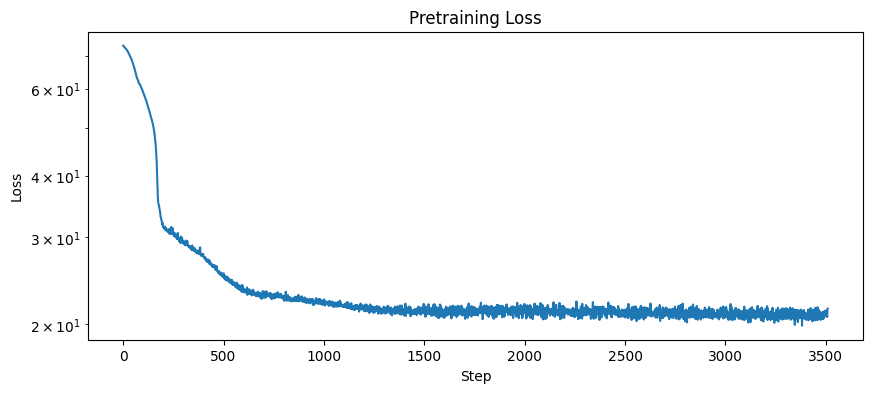

In [8]:
plt.figure(figsize=(10, 4))
plt.plot(pt_results['loss_history'])
plt.yscale('log')
plt.title('Pretraining Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()

### Pretraining Evals

In [9]:
eval_ctx = EvalContext.from_trained_model(model, decoder=None, data_root=data_cfg.data_root, config={
    'num_genes': model_cfg.num_genes, 'embed_dim': model_cfg.embed_dim, 
    'n_layer': model_cfg.n_layer, 'heads': model_cfg.heads, 'batch_size': pt_cfg.batch_size
})
pt_eval_results = run_pretraining_evals(eval_ctx)

save_report(pt_eval_results, data_cfg.eval_results_dir / 'pretraining_eval_report.json')
pt_eval_results

Using cpu
found 4 shards for split test
loading /Users/djemec/data/jepa/v0_4/training/test/shard_k562e_test_0000.npz


batch_invariance: Extracting embeddings:  26%|████████▍                        | 312/1213 [00:24<01:00, 14.94it/s]

loading /Users/djemec/data/jepa/v0_4/training/test/shard_k562e_test_0002.npz


batch_invariance: Extracting embeddings:  51%|████████████████▉                | 624/1213 [00:46<00:42, 13.86it/s]

loading /Users/djemec/data/jepa/v0_4/training/test/shard_k562e_test_0003.npz


...

latent_space_health: Extracting embeddings:  77%|███████████████████████▏      | 936/1213 [01:13<00:19, 14.15it/s]

loading /Users/djemec/data/jepa/v0_4/training/test/shard_k562e_test_0003.npz


latent_space_health: Extracting embeddings: 100%|█████████████████████████████| 1213/1213 [01:32<00:00, 13.18it/s]


latent_space_health: Eff_dim_90=1/8, Mean_var=0.0109, Isotropy=0.000000
Saved report to /Users/djemec/data/jepa/v0_6/eval_results/pretraining_eval_report.json


{'batch_invariance': {'config': {'samples': 38816,
   'embedding_dim': 8,
   'num_batches': 48,
   'num_perturbations': 286},
  'batch_classifier': {'accuracy': 0.02099433281813498,
   'chance': 0.020833333333333332,
   'above_chance_ratio': 1.007727975270479},
  'perturbation_classifier': {'accuracy': 0.018031942297784646,
   'chance': 0.0034965034965034965,
   'above_chance_ratio': 5.157135497166409},
  'invariance_ratio': 0.8588957055214724},
 'gene_embedding_pathways': {'config': {'n_genes': 5000},
  'kegg': {'silhouette_score': -0.1958553045988083,
   'knn_accuracy': 0.25263157894736843,
   'n_classes': 54,
   'n_samples': 1140},
  'reactome': {'silhouette_score': -0.23283234238624573,
   'knn_accuracy': 0.24057788944723618,
   'n_classes': 73,
   'n_samples': 1592}},
 'essential_gene_prediction': {'config': {'matched_genes': 4454,
   'train_genes': 3563,
   'test_genes': 891},
  'regression': {'pearson_test': 0.1002122885833289,
   'spearman_test': 0.07392576781401287},
  'classi

In [10]:
del pt_train_loader, pt_val_loader, eval_ctx
gc.collect()
torch.cuda.empty_cache()

## Stage 2: Perturbation Alignment

In [11]:
align_train_loader = AlignmentLoader(
    batch_size=align_cfg.batch_size, 
    split='train', data_dir=data_cfg.data_root / 'pert_embd', 
    device=device, total_samples=1250)
align_val_loader = AlignmentLoader(
    batch_size=align_cfg.batch_size, 
    split='val', data_dir=data_cfg.data_root / 'pert_embd', 
    device=device)

found 1 shards for split train
loading /Users/djemec/data/jepa/v0_4/pert_embd/train/pert_pairs_crispri_train.npz
found 1 shards for split val
loading /Users/djemec/data/jepa/v0_4/pert_embd/val/pert_pairs_crispri_val.npz


In [ ]:
align_results = run_alignment(model, align_train_loader, align_val_loader, seq_banks, target_bank, align_cfg, device, data_cfg.checkpoint_dir)

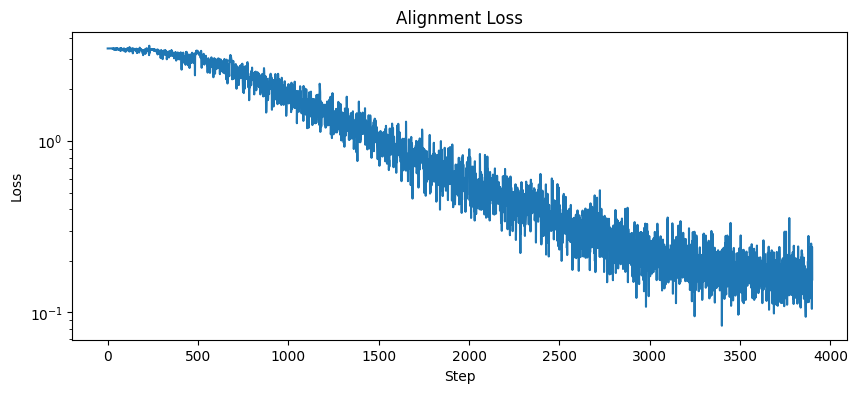

In [13]:
plt.figure(figsize=(10, 4))
plt.plot(align_results['loss_history'])
plt.yscale('log')
plt.title('Alignment Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()

### Alignment Evals

In [14]:
align_eval_ctx = EvalContext.from_trained_model(model, decoder=None, data_root=data_cfg.data_root, config={
    'num_genes': model_cfg.num_genes, 'embed_dim': model_cfg.embed_dim,
    'n_layer': model_cfg.n_layer, 'heads': model_cfg.heads, 'batch_size': align_cfg.batch_size
})
align_eval_results = run_alignment_evals(align_eval_ctx)

save_report(align_eval_results, data_cfg.eval_results_dir / 'alignment_eval_report.json')
align_eval_results

Using cpu
Loaded 1037 alignment pairs
Loaded input bank: torch.Size([1250, 1536])
Loaded anchor bank: torch.Size([1087, 320])
Computed alignment inference: DNA torch.Size([1250, 320]), Prot torch.Size([1087, 320])
alignment_recall: MRR=0.7842, Median_rank=1/1087
modality_gap_analysis: Centroid_dist=4.6070, Gap_ratio=1.20
anchor_input_consistency: Mean_cos_sim=0.6039, Std=0.0536
mode_sensitivity: Classification_acc=0.8278 (2.5x chance)
Loaded 27264 HGNC gene family annotations
target_family_probing: Accuracy=0.0938 (2.7x chance), Macro_F1=0.0770
Saved report to /Users/djemec/data/jepa/v0_6/eval_results/alignment_eval_report.json


{'alignment_recall': {'config': {'n_unique_dna': 1037,
   'n_pairs': 1037,
   'n_proteins': 1087},
  'metrics': {'mrr': 0.784200490926624,
   'median_rank': 1.0,
   'mean_rank': 1.7540983606557377},
  'recall_at_k': {'1': {'recall': 0.6528447444551592,
    'vs_random': 709.642237222758},
   '5': {'recall': 0.970106075216972, 'vs_random': 210.9010607521697},
   '10': {'recall': 0.9980713596914176, 'vs_random': 108.4903567984571},
   '20': {'recall': 1.0, 'vs_random': 54.35},
   '50': {'recall': 1.0, 'vs_random': 21.740000000000002}}},
 'modality_gap_analysis': {'config': {'n_dna': 1250,
   'n_protein': 1087,
   'latent_dim': 320},
  'centroids': {'distance': 4.607048034667969,
   'dna_variance': 7868.1689453125,
   'prot_variance': 343.5023498535156},
  'pairwise_distances': {'mean_within_dna': 122.80630419853695,
   'mean_within_prot': 25.34659499683346,
   'mean_between': 88.7653579711914,
   'gap_ratio': 1.1982939038423517}},
 'anchor_input_consistency': {'config': {'n_pairs': 1037},

In [15]:
del align_train_loader, align_val_loader, align_eval_ctx
gc.collect()
torch.cuda.empty_cache()

## Stage 3: Full Training

In [ ]:
train_loader = TrainingLoader(
    batch_size=full_cfg.batch_size, 
    split='train', data_dir=data_cfg.data_root / 'training', 
    device=device, total_samples=101682)
val_loader = TrainingLoader(
    batch_size=full_cfg.batch_size, 
    split='val', data_dir=data_cfg.data_root / 'training', 
    device=device, total_samples=11044)

full_results = run_full_training(model, train_loader, val_loader, seq_banks, target_bank, full_cfg, device, data_cfg.checkpoint_dir)

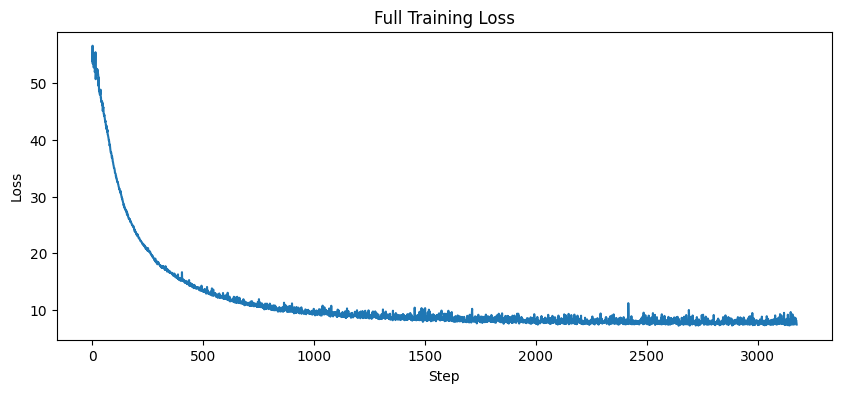

In [17]:
plt.figure(figsize=(10, 4))
plt.plot(full_results['loss_history'])
plt.title('Full Training Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()

In [18]:
del train_loader, val_loader
gc.collect()
torch.cuda.empty_cache()

## Linear Decoder Training

In [ ]:
decoder_train_loader = TrainingLoader(
    batch_size=full_cfg.batch_size, 
    split='train', data_dir=data_cfg.data_root / 'training', 
    device=device, 
    total_samples=101682)
decoder_val_loader = TrainingLoader(
    batch_size=full_cfg.batch_size,
    split='val', data_dir=data_cfg.data_root / 'training',
    device=device,
    total_samples=11044)

decoder = train_linear_decoder(model, decoder_train_loader, decoder_val_loader, seq_banks, target_bank, model_cfg, device, data_cfg.checkpoint_dir, decoder_cfg)

## Full Model Evals

In [20]:
eval_ctx = EvalContext.from_trained_model(model, decoder=decoder, data_root=data_cfg.data_root, config={
    'num_genes': model_cfg.num_genes, 'embed_dim': model_cfg.embed_dim,
    'n_layer': model_cfg.n_layer, 'heads': model_cfg.heads, 'batch_size': full_cfg.batch_size
})
full_eval_results = run_full_model_evals(eval_ctx)

save_report(full_eval_results, data_cfg.eval_results_dir / 'full_model_eval_report.json')
full_eval_results

Using cpu
found 4 shards for split test
loading /Users/djemec/data/jepa/v0_4/training/test/shard_k562e_test_0002.npz


Running test inference:   0%|                                                            | 0/1213 [00:00<?, ?it/s]

Loaded input bank: torch.Size([1250, 1536])


Running test inference:  26%|████████████▊                                     | 312/1213 [01:15<03:17,  4.55it/s]

loading /Users/djemec/data/jepa/v0_4/training/test/shard_k562e_test_0003.npz


...

Running test inference: 100%|█████████████████████████████████████████████████| 1213/1213 [04:38<00:00,  4.36it/s]


Aggregated 286 perturbations, 38816 samples
expression_prediction: MSE=0.5868, R2_all=0.7106
gene_level_analysis: Dir_acc=0.6041, Top50_acc=0.3713


perturbation_retrieval: Evaluating: 100%|███████████████████████████████████████| 100/100 [14:33<00:00,  8.74s/it]


perturbation_retrieval: MRR=0.0063, Median_rank=580
uncertainty_calibration: ECE=0.1791, Monotonicity=77.78%
action_vector_pathways: KEGG sil=-0.4129, kNN=0.3650
moa_matching: Within=0.9657, Between=0.9646, Ratio=1.001x
Saved report to /Users/djemec/data/jepa/v0_6/eval_results/full_model_eval_report.json


{'expression_prediction': {'config': {'test_perturbations': 286,
   'genes': 5000,
   'test_samples': 38816},
  'sample_level': {'mse': 0.5868173241615295,
   'pearson_r_top20': 0.8741776347160339},
  'perturbation_level': {'r2_all_genes': {'mean': 0.7105954897987259,
    'median': 0.7229295372962952},
   'r2_top50_degs': {'mean': -0.3172546152051512,
    'median': -0.1266346573829651},
   'mse': {'mean': 0.09100588411092758, 'median': 0.0866449624300003}},
  'severity': {'pearson_r': 0.8451735973358154,
   'spearman_r': 0.4794382099849112},
  'error_by_magnitude': {'0-0.25': {'mae': 0.23184657096862793,
    'count': 1324710},
   '0.25-0.5': {'mae': 0.29292112588882446, 'count': 93608},
   '0.5-1.0': {'mae': 0.47258275747299194, 'count': 9628},
   '1.0-1.5': {'mae': 0.8185152411460876, 'count': 958},
   '1.5-2.0': {'mae': 1.1260408163070679, 'count': 991},
   '2.0+': {'mae': 1.5104646682739258, 'count': 105}}},
 'gene_level_analysis': {'config': {'test_perturbations': 286,
   'genes': 

In [24]:
del decoder_train_loader, decoder_val_loader, eval_ctx
gc.collect()
torch.cuda.empty_cache()

## Summary

In [25]:
print('=== Training Complete ===')
print(f'Pretraining final loss: {pt_results["final_loss"]:.5f}')
print(f'Alignment final loss: {align_results["final_loss"]:.5f}')
print(f'Full training final loss: {full_results["final_loss"]:.5f}')
print(f'\nCheckpoints saved to: {data_cfg.checkpoint_dir}')
print(f'Eval reports saved to: {data_cfg.eval_results_dir}')

=== Training Complete ===
Pretraining final loss: 21.50136
Alignment final loss: 0.15573
Full training final loss: 7.44378

Checkpoints saved to: /Users/djemec/data/jepa/v0_6/checkpoints
Eval reports saved to: /Users/djemec/data/jepa/v0_6/eval_results
